# Open Clusters with OCCAM

## Learning Goals
By the end of this tutorial, you will:
- Understand the structure of the BOSS Open Cluster Chemical Abundance and Mapping (OCCAM) Value Added Catalog (VAC)
- Recreate common plots used to study Galactic chemical evolution
- Gain insight into the data quality

## Introduction
Open clusters have been used as tracers to study Galactic chemical evolution and dynamics as far back as [1979](https://ui.adsabs.harvard.edu/abs/1979ApJS...39..135J/abstract). For many decades, studies necessarily relied on data taken on a variety of instruments in order to encorporate even a few dozen clusters. The Apache Point Observatory Galactic Evolution Experiment (APOGEE) fundamentally changed this landscape, with DR17 containing data from over 120 open clusters taken on a single instrument. The OCCAM project was created to leverage this uniform dataset for studying the Galaxy using open clusters.

The BOSS OCCAM VAC is the first OCCAM catalog of optical data.

## Imports
This tutorial requires three commonly used python packages, and an SDSS specific package
- _numpy_ for doing large array operations
- _matplotlib_ for plotting
- _astropy_ for reading fits table
- _scipy_ for data fitting
- _sdss_access_ for SDSS data

Missing packages can be installed via `pip install numpy matplotlib astropy scipy sdss-access`

In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.optimize as opt

import sdss_access

_sdss-access_ is a convenient way to access SDSS data. The code below checks if a file exists (for example if you run this code on SciServer), and if not the files will be downloaded. They are saved to `$SAS_BASE_DIR`, using the standard SAS structure, and by default `$SAS_BASE_DIR` is `$HOME/sas`, but you should feel free to point it anywhere (e.g. an attached large storage).

In [2]:
sdss_path = sdss_access.path.Path(release='dr20', verbose=True)
access = sdss_access.Access(release='dr20', verbose=True)

occam_cluster_file = sdss_path.full('boss_occam_cluster', v_vac='DR20-v1')
occam_member_file = sdss_path.full('boss_occam_member', v_vac='DR20-v1')

if not sdss_path.exists('',full=occam_cluster_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('boss_occam_cluster', v_vac='DR20-v1')
    access.set_stream()
    access.commit()
    occam_cluster_file = sdss_path.full('boss_occam_cluster', v_vac='DR20-v1')
if not sdss_path.exists('',full=occam_member_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('boss_occam_member', v_vac='DR20-v1')
    access.set_stream()
    access.commit()
    occam_member_file = sdss_path.full('boss_occam_member', v_vac='DR20-v1')

Let's start by reading in the clusters file and seeing what data is available.

In [3]:
clusters = Table.read(occam_cluster_file)
clusters

Name,GLON,GLAT,RAdeg,DEdeg,EH_Radius,EH_PMRA,EH_PMRA_ERR,EH_PMDE,EH_PMDE_ERR,V_RAD,V_RAD_ERR,R_GC_EH,R_GC_Cav,EH_logAge,Cav_logAge,R_Guide,Z_Height,Z_Max,Azimuth_Angle,Eccentricity,Z_Period_Avg,Radial_Period_Avg,Fe_H,Fe_H_ERR,alpha_M,alpha_M_ERR,Num_Full_Members,Num_PMRV_Members,OCCAM_Qual,Cav_Qual,EH_Dist,Cav_Dist,X,Y,Z
,,,,,,,,,,,,,,,,kpc,,kpc,deg,,Myr,Myr,,,,,,,,,,,,,
bytes20,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,float64,float64
ASCC_127,112.468,4.409,347.302,65.183,4.249,7.41,0.017,-1.645,0.023,-13.3,4.9,8.27,8.28,7.09,6.98,8.6,0.05,0.05,177.6,0.01,80.0,168.3,0.21,0.02,-0.02,0.02,3,4,1,0,374.2,385.5,-8268.2,355.1,75.0
ASCC_58,281.705,1.263,153.706,-55.02,1.835,-13.302,0.016,2.76,0.018,10.6,3.8,8.04,8.04,7.76,7.45,8.33,0.03,0.06,183.4,0.01,76.6,162.1,0.0,0.02,0.03,0.03,3,3,1,0,471.4,496.6,-8020.9,-486.1,52.3
ASCC_71,299.989,-4.826,185.169,-67.521,0.55,-9.358,0.015,-1.361,0.013,-8.7,4.0,7.59,7.6,8.33,8.27,7.93,-0.08,0.1,187.6,0.02,73.2,153.1,-0.08,0.02,0.02,0.02,4,8,1,0,1222.4,1196.7,-7526.8,-1033.2,-60.4
Alessi-Teutsch_8,297.062,1.363,180.703,-60.953,0.521,-6.645,0.007,1.672,0.007,-14.6,4.7,7.73,7.72,8.13,8.57,8.55,0.04,0.13,186.3,0.08,84.0,169.1,-0.2,0.02,0.03,0.02,3,3,1,0,976.7,981.7,-7675.6,-874.1,63.7
Alessi_2,152.327,6.336,71.557,55.184,1.521,-0.928,0.013,-1.095,0.012,-11.5,3.2,8.66,8.67,8.42,8.4,9.44,0.09,0.1,178.2,0.08,96.0,190.2,-0.01,0.03,0.01,0.02,9,9,2,0,604.1,619.4,-8667.1,285.6,111.8
Alessi_21,223.373,-0.079,107.592,-9.318,2.577,-5.501,0.013,2.653,0.013,39.5,4.7,8.54,8.56,7.9,7.79,8.9,0.02,0.04,182.7,0.05,84.1,175.8,-0.07,0.03,0.05,0.04,15,22,2,0,560.8,597.0,-8553.9,-412.2,41.8
Alessi_24,328.928,-14.72,260.978,-62.818,1.843,-0.43,0.012,-8.963,0.014,11.2,4.1,7.73,7.7,8.0,7.41,7.82,-0.11,0.13,181.8,0.06,73.2,150.9,0.09,0.04,-0.03,0.02,7,7,2,0,476.7,510.5,-7698.7,-254.4,-87.8
Alessi_31,15.36,7.664,267.748,-11.857,1.985,-1.13,0.014,-4.167,0.013,2.5,5.4,7.5,7.45,8.18,8.1,7.85,0.11,0.13,178.6,0.05,73.8,151.7,-0.09,0.04,0.05,0.06,5,6,2,0,658.3,704.7,-7448.3,184.9,134.3


The most common plot, historically, we can make with this data is to plot the Galactic metallicity gradient. Recent studies prefer to use the "guiding radius" rather than the observed radius (e.g. [Otto et al. 2026](https://ui.adsabs.harvard.edu/abs/2026AJ....171...91O/abstract)). This still isn't a perfect measurement of the "birth" radius of a cluster since there is strong evidence clusters can experience significant radial migration, but it is better than assuming the current position is representative.

There is some debate about whether a linear fit appropriately characterizes the trend, or whether some more complex function is needed. Most of this debate involves more distant clusters as the trend does tend to flatten out towards the outer Galaxy. Since this sample does not extend signicantly into the outer Galaxy, a simple linear fit will suffice.

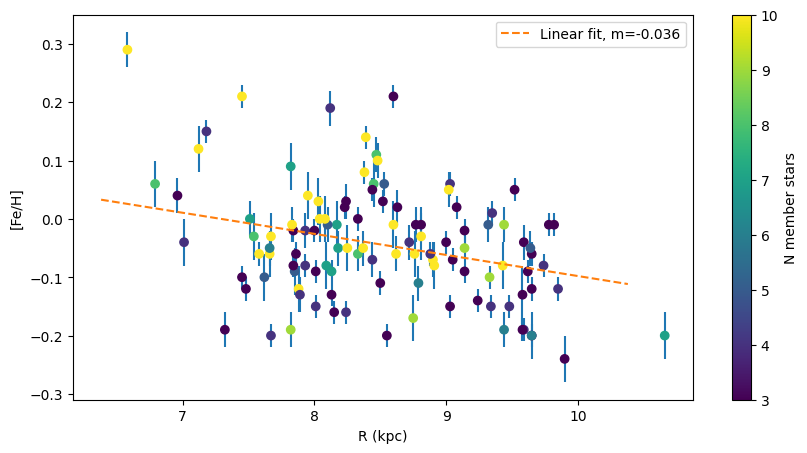

In [4]:
def linear(x, m, b):
    return m * x + b

popt, pcov = opt.curve_fit(linear, clusters["R_Guide"], clusters["Fe_H"], sigma=clusters["Fe_H_ERR"])
dummy_x = np.arange(np.min(clusters["R_Guide"]) - 0.2, np.max(clusters["R_Guide"]) + 0.2, 0.5)

plt.figure(figsize=(10, 5))
plt.errorbar(clusters["R_Guide"], clusters["Fe_H"], yerr=clusters["Fe_H_ERR"], fmt=".", zorder=1)
plt.scatter(clusters["R_Guide"], clusters["Fe_H"], c=clusters["Num_Full_Members"], vmax=10, zorder=2)
plt.plot(dummy_x, linear(dummy_x, *popt), "--", label=f"Linear fit, m={popt[0]:.3f}")
plt.ylabel("[Fe/H]")
plt.xlabel("R (kpc)")
plt.colorbar(label="N member stars")
plt.legend()

The OCCAM VAC also includes a file with all stars considered as potential cluster members. Note the **potential** members caveat will be relevant! Let's read in that file and see what's in it.

In [5]:
members = Table.read(occam_member_file)
members

Cluster,SDSS_ID,GaiaDR3_ID,GLON,GLAT,RAdeg,DEdeg,V_RAD,E_V_RAD,PMRA,E_PMRA,PMDE,E_PMDE,FeH_CLAM,E_FeH_CLAM,alpha_M_CLAM,E_alpha_M_CLAM,EH_Prob,RV_Prob,FeH_Prob_CLAM,Teff,logg
bytes20,int64,int64,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64
ASCC_127,68662847,2208580141903286144,146.524,4.093,346.209,64.641,-12.3,4.2,7.35,0.074,-1.498,0.08,0.21,0.01,-0.02,0.01,0.617,0.894,0.986,3742.5,5.0
ASCC_127,68662927,2208589285893434368,146.47,4.143,346.273,64.707,-11.5,5.3,7.407,0.069,-1.773,0.07,0.22,0.01,-0.03,0.01,0.95,0.742,0.948,3747.1,5.0
ASCC_127,68663648,2208645738945746944,143.853,4.01,349.266,65.084,-2.7,11.9,7.52,0.049,-2.131,0.045,0.09,0.01,-0.02,0.01,0.896,0.0,0.0,3676.9,4.9
ASCC_127,68698094,2212250655312637952,147.479,6.441,345.224,67.033,37.8,7.0,7.545,0.072,-1.213,0.076,0.05,0.01,-0.02,0.01,0.683,0.0,0.0,3631.5,5.0
ASCC_127,68697065,2212114178432555008,148.503,5.549,343.997,65.819,-20.9,5.1,7.077,0.075,-1.494,0.063,0.31,0.01,-0.04,0.01,0.838,0.012,0.0,3791.2,5.0
ASCC_127,68695236,2211885381233908864,147.224,5.119,345.446,65.622,-16.0,5.1,7.435,0.07,-1.491,0.068,0.2,0.01,-0.02,0.01,0.727,0.593,0.928,3719.0,4.9
ASCC_127,68664251,2208699099620479360,144.826,4.086,348.156,64.982,-11.5,4.6,7.647,0.071,-1.877,0.077,0.26,0.01,-0.02,0.01,1.0,0.731,0.1,3808.3,5.0
ASCC_58,97074499,5352267783350622720,91.995,1.403,157.587,-56.254,11.4,2.9,-13.529,0.018,1.929,0.018,-0.0,0.01,0.06,0.01,0.668,0.973,0.932,5092.8,4.2
ASCC_58,97070667,5352033553017681408,93.503,1.78,159.368,-56.392,11.6,2.6,-13.717,0.017,1.939,0.018,0.01,0.01,0.04,0.01,0.605,0.957,0.981,5074.3,4.3


"Cluster" corresponds exactly to "Name" in the clusters file, so we can match on that keyword. OCCAM membership probabilities are calculated based on radial velocity and [Fe/H]. A number of other parameters (coordinates, some stellar properties) are also provided for convenience. 

Details of membership determination can be found in [Otto et al. 2026](https://ui.adsabs.harvard.edu/abs/2026AJ....171...91O/abstract), but briefly we'll note that stars are considered reliable members if they have FeH_Prob_CLAM > 0.14 && RV_Prob > 0.14 && EH_Prob > 0.14. RV and Fe/H probabilities are computed by the OCCAM pipeline. Early versions of OCCAM pipeline also used 2 dimensional proper motion to determine membership, but more sophisticated 5 dimensional density estimations of membership from Gaia data now exist (e.g. [Cantat-Gaudin et al. 2020](https://ui.adsabs.harvard.edu/abs/2020A%26A...633A..99C/abstract) and [Hunt and Reffert 2023](https://ui.adsabs.harvard.edu/abs/2023A%26A...673A.114H/abstract)) so OCCAM now includes EH_Prob instead.

To get an idea of the spread of stellar abundances in an individual cluster, as measured from BOSS data using the CLAM pipeline, let's select all the member stars in a cluster and plot them compared to the OCCAM measurement for the cluster. There are over 100 clusters in the VAC; helpfully if we limit exercise to clusters with only 10 or more members it's almost the same length as the "tab20" color sequence so we can use fairly distinct colors to identify clusters.

Adding a lower alpha to stars allows points to "stack" and become more prominent. While not perfect groups, the colors do group fairly well. Considering the entire y-range (~0.25 dex) is only 10x the cluster median, the groupings seem quite good.

Average alpha/m uncertainty 0.02


Text(0, 0.5, '[$\\alpha$/M]')

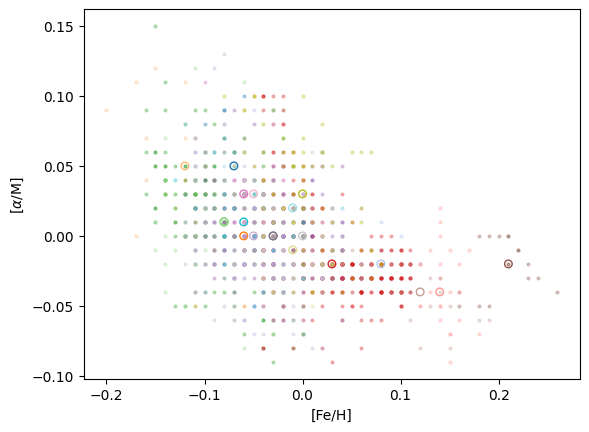

In [6]:
print("Average alpha/m uncertainty", np.median(clusters["alpha_M_ERR"]))
colors = mpl.color_sequences["tab20"]
i = 0
for cluster in clusters:
    if cluster["Num_Full_Members"] < 10 or i > 19:
        continue
    stars = members[np.where(members["Cluster"] == cluster["Name"])]
    stars = stars[(stars["FeH_Prob_CLAM"] > 0.14) & (stars["RV_Prob"] > 0.14) & (stars["EH_Prob"] > 0.14)]
    plt.scatter(stars["FeH_CLAM"], stars["alpha_M_CLAM"], color=colors[i], s=4, alpha=0.3)
    plt.scatter(cluster["Fe_H"], cluster["alpha_M"], edgecolors=colors[i], marker="o", facecolors='none', s=30)
    i += 1
plt.xlabel("[Fe/H]")
plt.ylabel(r"[$\alpha$/M]")

"Quite good" isn't particularly scientific. We can turn the above plot into something much more descriptive by actually measuring the 1-sigma scatter in the data.

Text(0, 0.5, '[$\\alpha$/M]')

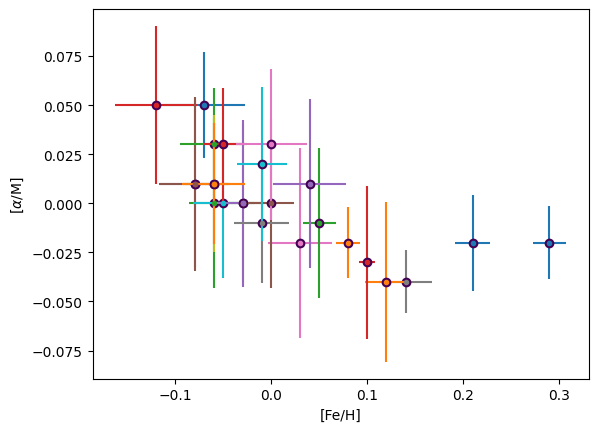

In [7]:
for cluster in clusters:
    if cluster["Num_Full_Members"] < 10:
        continue
    stars = members[np.where(members["Cluster"] == cluster["Name"])]
    stars = stars[(stars["FeH_Prob_CLAM"] > 0.1) & (stars["RV_Prob"] > 0.14) & (stars["EH_Prob"] > 0.4)]
    plt.errorbar(cluster["Fe_H"], cluster["alpha_M"],
                 yerr=np.std(stars["FeH_CLAM"]), xerr=np.std(stars["alpha_M_CLAM"]),
                 fmt=".", zorder=1)
    plt.scatter(cluster["Fe_H"], cluster["alpha_M"], c=cluster["Num_Full_Members"])
plt.xlabel("[Fe/H]")
plt.ylabel(r"[$\alpha$/M]")

### About this notebook

This notebook was created to explore the BOSS OCCAM VAC.

**Authors**: John Donor

**Last Update**: 2026 May 20

If you use `astropy`  for published research, please cite the
authors. Follow this link for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.